# 01 Mdp Example

## 📚 Learning Objectives

By completing this notebook, you will:
- Formalize decision problems as MDPs
- Define states, actions, rewards, and transitions

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 1**.

---


## Before This Lesson: What Is Reinforcement Learning?

Reinforcement Learning (RL) is a branch of machine learning where an **agent** learns by interacting with an **environment** and receiving **rewards** based on its actions.

Instead of being shown the correct answer directly, the agent improves over time by trying actions, observing outcomes, and adjusting its behavior to achieve better long-term results.

In this course, students will move from the basic RL framework to classical methods, deep RL, exploration strategies, and practical applications.

Why start with MDPs? Because the MDP is the first precise model that helps students describe a decision problem before solving it with any RL algorithm.

So before asking *how the agent learns*, this lesson first answers a more basic question:

`How do we describe the world, the decisions, and the rewards in a form an RL system can understand?`

## Lesson Brief

This lesson introduces the basic language of reinforcement learning through a very small Markov Decision Process (MDP).

You will see what a **state**, **action**, **reward**, **transition**, and **policy** actually mean before any algorithm appears.

Why this matters: if students do not understand the MDP structure first, later topics like value iteration and Q-learning become formulas without meaning.

This notebook is the foundation for the rest of Unit 1.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **David Silver - "RL Course Lecture 2: Markov Decision Process"**:
[Watch on YouTube](https://www.youtube.com/watch?v=lfHX2hHRMVQ)

Why this pick:
- Strong coverage of states, actions, rewards, policies, and Bellman intuition.
- Best fit when students need the theory behind a small MDP before algorithms.

## MDP Anatomy and the Markov Idea

Before solving anything, students need one clear picture of what an MDP is doing.

An MDP gives us a clean way to describe a decision problem using five parts:

1. **States**: what situation the agent is in.
2. **Actions**: what choices are available.
3. **Transitions**: what next state can happen after an action.
4. **Rewards**: what immediate feedback is received.
5. **Policy**: what action the agent chooses in each state.

### Why do we build this structure first?

Because later algorithms do not invent the problem. They only work **on top of** this description.

If the MDP is unclear, then value functions, Bellman updates, Q-learning, and policy gradients will all feel like disconnected formulas.

### What does "Markov" mean here?

The Markov idea says that the **current state should contain enough information** to choose and evaluate the next action.

In plain language:

> If the state is defined well, the agent should not need the full history every time it makes a decision.

That does **not** mean history never matters. It means we try to define the state so that the useful information from history is already summarized inside the current state.

### Mini teaching example

If you are navigating a grid world, the current square may be enough.
If you are trading stocks, the current state might need prices, trend features, and portfolio information.
If those are missing, the state is poorly defined and the MDP is weak.

### Question to keep in mind

When you look at the code below, ask:

`Did we define the world clearly enough that an algorithm could learn from it later?`

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- State: the information that describes the current situation.
- Action: one legal move the agent can choose.
- Reward: immediate feedback after an action.
- Transition: how the environment moves from one state to the next.
- Policy: the decision rule that tells the agent what action to take.
- Terminal state: a state where the episode ends.

### What belongs to the environment, and what belongs to the agent?
- Environment side: states, transition rule, rewards, terminal states.
- Agent side: the policy.
- This distinction matters because the **world** decides what happens after an action, but the **agent** decides which action to try.

### Quick Check
- Can you separate environment pieces from agent pieces?
- Why do we define states and actions before solving?
- What part of the notebook tells you what success means?
- If the reward changes but the policy stays the same, which part of the problem changed?

### Common Mistakes
- Mixing state with reward.
- Thinking the policy creates the reward.
- Reading one transition as the whole problem.
- Thinking the agent controls the next state directly instead of acting through the environment.


# Example 1: A Simple Markov Decision Process

This notebook gives you a concrete MDP before you move to policy evaluation,
policy iteration, and value iteration.

## What you should learn

By the end of this notebook, you should be able to:
- identify states, actions, rewards, and transitions in a simple problem
- describe an MDP using a small grid world
- read a policy as a mapping from states to actions
- understand why an MDP is the starting point for RL

## Before you start

You should already be comfortable with:
- basic Python syntax
- lists, dictionaries, and functions
- the RL terms `agent`, `environment`, and `reward`

## Study tip

Do not try to memorize definitions only.

Focus on answering this question:

`If I had to teach this problem to a computer, what information would I need to define first?`


## Inputs and Outputs

**Inputs**
- a tiny 3x3 grid world
- a small reward table
- a deterministic transition rule
- a hand-written example policy

**Outputs**
- a readable description of the MDP components
- example transitions from one state to the next
- a simple policy rollout showing how decisions accumulate reward


### Step Guide

**What this cell does:** Loads NumPy and Matplotlib, then defines the tiny 3×3 **grid**, the **action names**, and the **move map** used in every cell below.

**How to read it (weak Python OK):** Treat this as a settings screen. Circle these names: `ACTIONS`, `ACTION_TO_DELTA`, `START`, `GOAL`, and `PIT`.

**What to expect in the output:** Often nothing yet from imports—later prints will use these variables.

**If you feel lost:** Skip the dict punctuation on the first pass; only notice that each action points to a `(row, col)` step.


Example 1: Markov Decision Process (MDP)

1. States
[(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]

2. Actions
['up', 'right', 'down', 'left']

3. Rewards
  (0, 0): -0.1
  (0, 1): -0.1
  (0, 2): -0.1
  (1, 0): -0.1
  (1, 1): -3.0
  (1, 2): -0.1
  (2, 0): -0.1
  (2, 1): -0.1
  (2, 2): 5.0

4. Example transitions
  state=(0, 0), action=right -> next_state=(0, 1), reward=-0.1
  state=(0, 2), action=down -> next_state=(1, 2), reward=-0.1
  state=(1, 0), action=right -> next_state=(1, 1), reward=-3.0
  state=(2, 1), action=right -> next_state=(2, 2), reward=5.0

5. Example policy
  (0, 0) -> right
  (0, 1) -> right
  (0, 2) -> down
  (1, 0) -> down
  (1, 2) -> down
  (2, 0) -> right
  (2, 1) -> right

Checkpoint questions:
- Which parts of this problem belong to the environment?
- Which part represents the agent's decision rule?
- Why do we separate transitions from rewards?


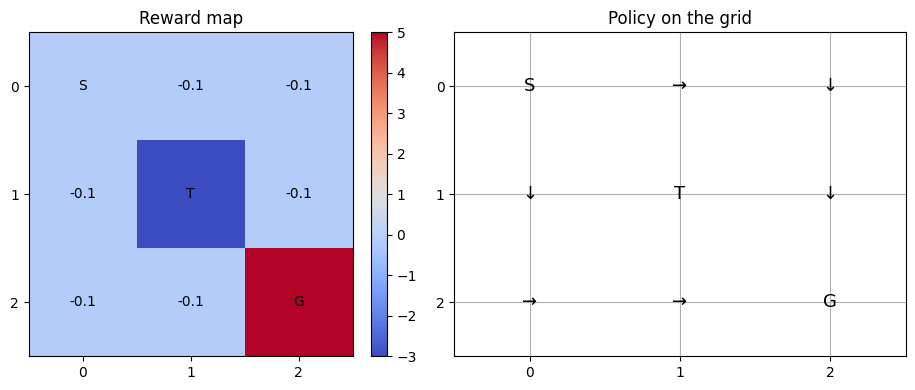

In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Keep the environment tiny so students can inspect every state by eye.
# Save a value in a name so the next lines can read it.
GRID_SIZE = 3

# The agent can choose one of four movement actions in each non-terminal state.
# Create the list of action names (their indices are the numeric action ids).
ACTIONS = ["up", "right", "down", "left"]
# Save a value in a name so the next lines can read it.
ACTION_TO_DELTA = {
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "up": (-1, 0),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "right": (0, 1),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "down": (1, 0),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "left": (0, -1),
# Part of a dict/set literal layout (syntax grouping).
}
# Map each action id to a Unicode arrow symbol for policy printing/plotting.
ACTION_TO_ARROW = {
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "up": "↑",
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "right": "→",
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "down": "↓",
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "left": "←",
# Part of a dict/set literal layout (syntax grouping).
}

# Name the important locations so they are easy to reference later.
# Save a value in a name so the next lines can read it.
START = (0, 0)
# Another assignment—same idea: store a value for the lines below.
GOAL = (2, 2)
# Another assignment—same idea: store a value for the lines below.
TRAP = (1, 1)
# Another assignment—same idea: store a value for the lines below.
STEP_COST = -0.1

# Enumerate all possible states in the grid world.
# Save a value in a name so the next lines can read it.
states = [(r, c) for r in range(GRID_SIZE) for c in range(GRID_SIZE)]

# Rewards belong to the environment, not to the policy.
# Unpack the one-step model output from transition(state, action).
rewards = {state: STEP_COST for state in states}
# Unpack the one-step model output from transition(state, action).
rewards[GOAL] = 5.0
# Unpack the one-step model output from transition(state, action).
rewards[TRAP] = -3.0


# Function `transition` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state, action.
def transition(state, action):
    # Terminal states stop the episode, so the agent stays there.
    # If the condition is True, run the indented block under this line.
    if state in {GOAL, TRAP}:
        # Send a value back to whoever called this function.
        return state

    # Convert the chosen action into a movement on the grid.
    # Save a value in a name so the next lines can read it.
    dr, dc = ACTION_TO_DELTA[action]
    # Another assignment—same idea: store a value for the lines below.
    nr = min(max(state[0] + dr, 0), GRID_SIZE - 1)
    # Another assignment—same idea: store a value for the lines below.
    nc = min(max(state[1] + dc, 0), GRID_SIZE - 1)
    # Send a value back to whoever called this function.
    return (nr, nc)


# Function `draw_reward_and_policy_map` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: policy.
def draw_reward_and_policy_map(policy):
    # Build a 2D reward table so students can see the environment structure visually.
    # Unpack the one-step model output from transition(state, action).
    reward_grid = np.array([[rewards[(r, c)] for c in range(GRID_SIZE)] for r in range(GRID_SIZE)])

    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Left: show where positive and negative rewards are placed.
    # Capture the AxesImage object returned by imshow (used for the colorbar).
    im = axes[0].imshow(reward_grid, cmap="coolwarm")
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    axes[0].set_title("Reward map")
    # Same plot panel as the line above—one more small plotting tweak.
    axes[0].set_xticks(range(GRID_SIZE))
    # Same plot panel as the line above—one more small plotting tweak.
    axes[0].set_yticks(range(GRID_SIZE))
    # Start a loop: repeat the indented block once per item in the sequence.
    for r in range(GRID_SIZE):
        # Start a loop: repeat the indented block once per item in the sequence.
        for c in range(GRID_SIZE):
            # Create or choose a variable used in the Bellman warm-up demo.
            state = (r, c)
            # If the condition is True, run the indented block under this line.
            if state == START:
                # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
                label = "S"
            # Else-if: only checked when the earlier if/elif tests were False.
            elif state == GOAL:
                # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
                label = "G"
            # Else-if: only checked when the earlier if/elif tests were False.
            elif state == TRAP:
                # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
                label = "T"
            # Else: run this block when none of the if/elif tests above matched.
            else:
                # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
                label = f"{rewards[state]:.1f}"
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            axes[0].text(c, r, label, ha="center", va="center", color="black")
    # Change something about the whole figure (not just one small subplot).
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    # Right: show the policy separately so students distinguish rewards from decisions.
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_title("Policy on the grid")
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_xlim(-0.5, GRID_SIZE - 0.5)
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_ylim(GRID_SIZE - 0.5, -0.5)
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_xticks(range(GRID_SIZE))
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_yticks(range(GRID_SIZE))
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].grid(True)
    # Start a loop: repeat the indented block once per item in the sequence.
    for r in range(GRID_SIZE):
        # Start a loop: repeat the indented block once per item in the sequence.
        for c in range(GRID_SIZE):
            # Create or choose a variable used in the Bellman warm-up demo.
            state = (r, c)
            # If the condition is True, run the indented block under this line.
            if state == START:
                # Same plot panel as the line above—one more small plotting tweak.
                axes[1].text(c, r, "S", ha="center", va="center", fontsize=13)
            # Else-if: only checked when the earlier if/elif tests were False.
            elif state == GOAL:
                # Same plot panel as the line above—one more small plotting tweak.
                axes[1].text(c, r, "G", ha="center", va="center", fontsize=13)
            # Else-if: only checked when the earlier if/elif tests were False.
            elif state == TRAP:
                # Same plot panel as the line above—one more small plotting tweak.
                axes[1].text(c, r, "T", ha="center", va="center", fontsize=13)
            # Else: run this block when none of the if/elif tests above matched.
            else:
                # Same plot panel as the line above—one more small plotting tweak.
                axes[1].text(c, r, ACTION_TO_ARROW[policy[state]], ha="center", va="center", fontsize=13)
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


# This hand-written policy intentionally goes around the trap and toward the goal.
# Create or update the greedy policy array (one int action id per state).
policy = {
    # Execute: (0, 0): "right",
    (0, 0): "right",
    # Execute: (0, 1): "right",
    (0, 1): "right",
    # Execute: (0, 2): "down",
    (0, 2): "down",
    # Execute: (1, 0): "down",
    (1, 0): "down",
    # Execute: (1, 2): "down",
    (1, 2): "down",
    # Execute: (2, 0): "right",
    (2, 0): "right",
    # Execute: (2, 1): "right",
    (2, 1): "right",
# Part of a dict/set literal layout (syntax grouping).
}

# Show text or numbers in the cell output area under the code.
print("=" * 60)
# Show text or numbers in the cell output area under the code.
print("Example 1: Markov Decision Process (MDP)")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Show text or numbers in the cell output area under the code.
print("\n1. States")
# Show text or numbers in the cell output area under the code.
print(states)

# Show text or numbers in the cell output area under the code.
print("\n2. Actions")
# Show text or numbers in the cell output area under the code.
print(ACTIONS)

# Show text or numbers in the cell output area under the code.
print("\n3. Rewards")
# Start a loop: repeat the indented block once per item in the sequence.
for state in states:
    # Show text or numbers in the cell output area under the code.
    print(f"  {state}: {rewards[state]}")

# Show text or numbers in the cell output area under the code.
print("\n4. Example transitions")
# Save a value in a name so the next lines can read it.
examples = [
    # Execute: (START, "right"),
    (START, "right"),
    # Execute: ((0, 2), "down"),
    ((0, 2), "down"),
    # Execute: ((1, 0), "right"),
    ((1, 0), "right"),
    # Execute: ((2, 1), "right"),
    ((2, 1), "right"),
# Execute: ]
]
# Start a loop: repeat the indented block once per item in the sequence.
for state, action in examples:
    # Unpack the one-step model output from transition(state, action).
    next_state = transition(state, action)
    # Show text or numbers in the cell output area under the code.
    print(
        # Build text with {…} holes filled in by variables (an f-string).
        f"  state={state}, action={action} -> next_state={next_state}, "
        # Build text with {…} holes filled in by variables (an f-string).
        f"reward={rewards[next_state]}"
    # Close the parentheses opened earlier (end this function call / grouping).
    )

# Show text or numbers in the cell output area under the code.
print("\n5. Example policy")
# Start a loop: repeat the indented block once per item in the sequence.
for state, action in policy.items():
    # Show text or numbers in the cell output area under the code.
    print(f"  {state} -> {action}")

# Show text or numbers in the cell output area under the code.
print("\nCheckpoint questions:")
# Show text or numbers in the cell output area under the code.
print("- Which parts of this problem belong to the environment?")
# Show text or numbers in the cell output area under the code.
print("- Which part represents the agent's decision rule?")
# Show text or numbers in the cell output area under the code.
print("- Why do we separate transitions from rewards?")

# Execute: draw_reward_and_policy_map(policy)
draw_reward_and_policy_map(policy)


## Worked Example: Following a Policy Through the MDP

Now that the MDP is defined, the next step is to see what happens when an agent
actually follows a policy.

In the next cell, you will simulate one short episode starting from the start
state and observe how rewards accumulate over time.

Important note: in this notebook, the reward is attached to the **transition into the next state**. Also, once the agent reaches a terminal state, we stop the episode instead of pretending the policy still has a meaningful action there.

### Step Guide

**What this cell does:** Defines `rollout` plus the toy **transition and reward** rules so you can watch one walk through the grid.

**How to read it (weak Python OK):** Chase one story: *current state → choose action → next state → reward*. Every `print` is showing one step of that story.

**What to expect in the output:** Text lines that look like a tiny game log (states visited and rewards collected).

**If you feel lost:** Ignore nested `if` details at first—just check whether the agent ever reaches the goal or falls in the pit.


Policy rollout from the start state:

step 0: state=(0, 0), action=right, next_state=(0, 1), reward=-0.1
step 1: state=(0, 1), action=right, next_state=(0, 2), reward=-0.1
step 2: state=(0, 2), action=down, next_state=(1, 2), reward=-0.1
step 3: state=(1, 2), action=down, next_state=(2, 2), reward=5.0

Final state: (2, 2)
Total reward: 4.7

Reflection:
- Did the policy avoid the trap?
- What would happen if one action changed?
- How could a better policy be discovered automatically?


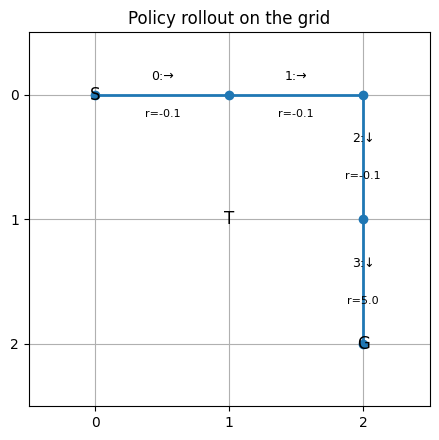

In [2]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `rollout` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: policy, start_state, max_steps.
def rollout(policy, start_state=START, max_steps=10):
    # Create or choose a variable used in the Bellman warm-up demo.
    state = start_state
    # Save a value in a name so the next lines can read it.
    trajectory = []
    # Another assignment—same idea: store a value for the lines below.
    total_reward = 0.0

    # Start a loop: repeat the indented block once per item in the sequence.
    for step_idx in range(max_steps):
        # Stop if the episode has already reached a terminal state.
        # If the condition is True, run the indented block under this line.
        if state in {GOAL, TRAP}:
            # Stop the loop completely and continue after the loop block.
            break

        # The policy chooses an action for the current state.
        # Save a value in a name so the next lines can read it.
        action = policy[state]

        # The environment responds with the next state.
        # Unpack the one-step model output from transition(state, action).
        next_state = transition(state, action)

        # The reward is attached to the state the agent arrives in.
        # Unpack the one-step model output from transition(state, action).
        reward = rewards[next_state]
        # Save a value in a name so the next lines can read it.
        total_reward += reward

        # Save the full step so we can inspect the episode afterward.
        # Add one new item to the end of a list (the list grows in place).
        trajectory.append((step_idx, state, action, next_state, reward))
        # Create or choose a variable used in the Bellman warm-up demo.
        state = next_state

        # If the condition is True, run the indented block under this line.
        if state in {GOAL, TRAP}:
            # Stop the loop completely and continue after the loop block.
            break

    # Send a value back to whoever called this function.
    return trajectory, total_reward, state


# Function `plot_trajectory` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: trajectory.
def plot_trajectory(trajectory):
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.set_xlim(-0.5, GRID_SIZE - 0.5)
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylim(GRID_SIZE - 0.5, -0.5)
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_xticks(range(GRID_SIZE))
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_yticks(range(GRID_SIZE))
    # Same plot panel as the line above—one more small plotting tweak.
    ax.grid(True)
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Policy rollout on the grid")

    # Start a loop: repeat the indented block once per item in the sequence.
    for r in range(GRID_SIZE):
        # Start a loop: repeat the indented block once per item in the sequence.
        for c in range(GRID_SIZE):
            # Create or choose a variable used in the Bellman warm-up demo.
            state = (r, c)
            # If the condition is True, run the indented block under this line.
            if state == START:
                # Same plot panel as the line above—one more small plotting tweak.
                ax.text(c, r, "S", ha="center", va="center", fontsize=12)
            # Else-if: only checked when the earlier if/elif tests were False.
            elif state == GOAL:
                # Same plot panel as the line above—one more small plotting tweak.
                ax.text(c, r, "G", ha="center", va="center", fontsize=12)
            # Else-if: only checked when the earlier if/elif tests were False.
            elif state == TRAP:
                # Same plot panel as the line above—one more small plotting tweak.
                ax.text(c, r, "T", ha="center", va="center", fontsize=12)

    # Draw the visited path in order so students can see the sequence of decisions.
    # Save a value in a name so the next lines can read it.
    path_points = [START] + [next_state for _, _, _, next_state, _ in trajectory]
    # Another assignment—same idea: store a value for the lines below.
    xs = [c for _, c in path_points]
    # Another assignment—same idea: store a value for the lines below.
    ys = [r for r, _ in path_points]
    # Same plot panel as the line above—one more small plotting tweak.
    ax.plot(xs, ys, marker="o", linewidth=2)

    # Annotate each move with the chosen action and received reward.
    # Start a loop: repeat the indented block once per item in the sequence.
    for step_idx, (_, state, action, next_state, reward) in enumerate(trajectory):
        # Save a value in a name so the next lines can read it.
        mid_x = (state[1] + next_state[1]) / 2
        # Another assignment—same idea: store a value for the lines below.
        mid_y = (state[0] + next_state[0]) / 2
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(mid_x, mid_y - 0.12, f"{step_idx}:{ACTION_TO_ARROW[action]}", ha="center", fontsize=9)
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(mid_x, mid_y + 0.18, f"r={reward}", ha="center", fontsize=8)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


# Save a value in a name so the next lines can read it.
trajectory, total_reward, final_state = rollout(policy)

# Show text or numbers in the cell output area under the code.
print("Policy rollout from the start state:\n")
# Start a loop: repeat the indented block once per item in the sequence.
for step_idx, state, action, next_state, reward in trajectory:
    # Show text or numbers in the cell output area under the code.
    print(
        # Build text with {…} holes filled in by variables (an f-string).
        f"step {step_idx}: state={state}, action={action}, "
        # Build text with {…} holes filled in by variables (an f-string).
        f"next_state={next_state}, reward={reward}"
    # Close the parentheses opened earlier (end this function call / grouping).
    )

# Show text or numbers in the cell output area under the code.
print("\nFinal state:", final_state)
# Show text or numbers in the cell output area under the code.
print("Total reward:", round(total_reward, 2))

# Show text or numbers in the cell output area under the code.
print("\nReflection:")
# Show text or numbers in the cell output area under the code.
print("- Did the policy avoid the trap?")
# Show text or numbers in the cell output area under the code.
print("- What would happen if one action changed?")
# Show text or numbers in the cell output area under the code.
print("- How could a better policy be discovered automatically?")

# Execute: plot_trajectory(trajectory)
plot_trajectory(trajectory)


## Summary

You now have a concrete MDP in mind.

The important idea is not the grid itself. The important idea is the structure:
- states describe situations
- actions describe choices
- rewards describe feedback
- transitions describe how the world changes
- a policy describes how the agent behaves

### What comes next

In `02_mdp_solving.ipynb`, you will move from describing an MDP to solving one.

In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.
"""))


## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.


### Step Guide

**What this cell does:** Tries to auto-build a **small recap plot** from numbers that already exist in the kernel (values, rewards, etc.).

**How to read it (weak Python OK):** If a chart appears, read axes first. If you see only text, the cell still ran—there may be nothing easy to plot.

**What to expect in the output:** One quick figure or a short “nothing plotted” style message.

**If you feel lost:** Use this as a second pass **after** you can narrate the MDP in words without the code.


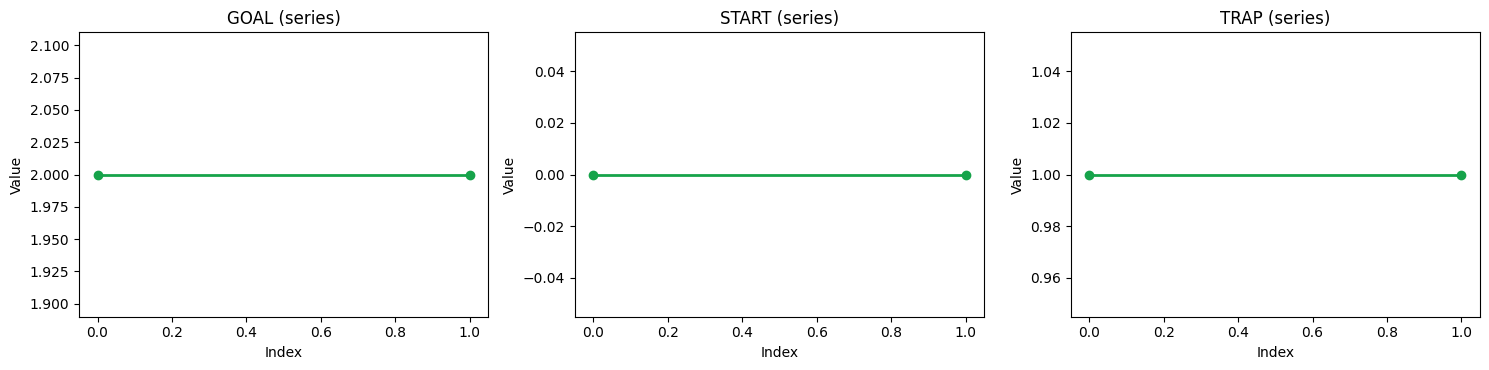

In [4]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** An MDP is the language that turns a decision problem into something an RL algorithm can work with: states, actions, rewards, transitions, and a policy.

**If students remember one idea:** Before solving a problem, define the environment clearly. A weak MDP definition creates weak RL reasoning later.

**Quick check before moving on:**
- Can you point to the state, action, reward, and transition rule in this example without looking back at the definitions?
- Can you explain why a policy is different from the environment dynamics?

**Bridge to the next step:** Next, you will move from describing an MDP to actually solving one.

**For weaker coders:** Sketch the 3×3 grid on paper, mark the goal and pit, and trace one action from `START`. If that picture makes sense, you already understand the MDP better than memorizing symbols.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


objc[41176]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11434c138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1148489c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


objc[41176]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11434c188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114848a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[41176]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11434bc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114848a68). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[41176]: Class SDLAppDelegate is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11434bcd8) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114848ab8). Th

Motion recap | return=0.0 | frames=3 | term=True | trunc=False


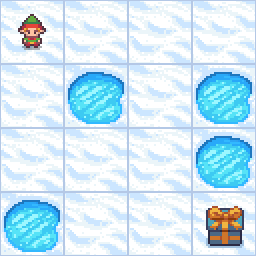

In [5]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz


def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
